In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis


## Understanding the Data

In [48]:
df.shape

(7043, 21)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [50]:
df = df.drop(["customerID"],axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## Data Manipulation

Turning the `SeniorCitizen` column to a non numerical column first(better for statistics).

In [52]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({1:'Yes', 0:"No"})

Though there's no null in df, we can find some indirect missingness in our data (which can be in form of blankspaces).


We'll first check the `MonthlyCharges` and `TotalCharges` cols since they are only columns contain numerical numbers but are not demographic features. 

In [53]:
df["TotalCharges"] = pd.to_numeric(df.TotalCharges, errors="coerce")
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [54]:
df[np.isnan(df["TotalCharges"])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


From the result we see that for those entries whose `TotalCharges` is Nan, their `tenure` are 0.

Let's see if there are any other 0 values in the tenure column.

In [55]:
df[df["tenure"]==0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

There are no additional missing values in the `tenure` column.
Let's delete the rows with missing values since there are only 11 rows and deleting them will not affect the data.

In [56]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

Next we do the same thing to `MonthlyChargs` column.

In [57]:
df["MonthlyCharges"] = pd.to_numeric(df.MonthlyCharges, errors="coerce")

In [58]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now there's no Nan in DataFrame. We can have a statistical overview of numerical data.

In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


Values we will predict("Churn" col) is highly imbalanced. 

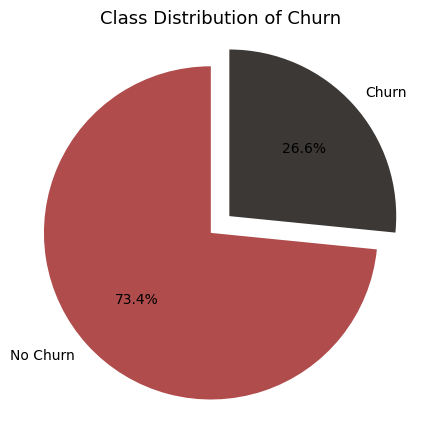

In [60]:
df1 = df.copy(deep=True)
churn_counts = df1["Churn"].value_counts()
labels = ["No Churn", "Churn"]
sizes = churn_counts.values

plt.figure(figsize=(5, 5))
plt.pie(
    sizes,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    explode=(0.05, 0.1),
    colors=["#B04C4C", "#3B3836"]
)
plt.title("Class Distribution of Churn", fontsize=13)
plt.axis("equal")
plt.show()

Use the correlation heatmap to check collinearity.

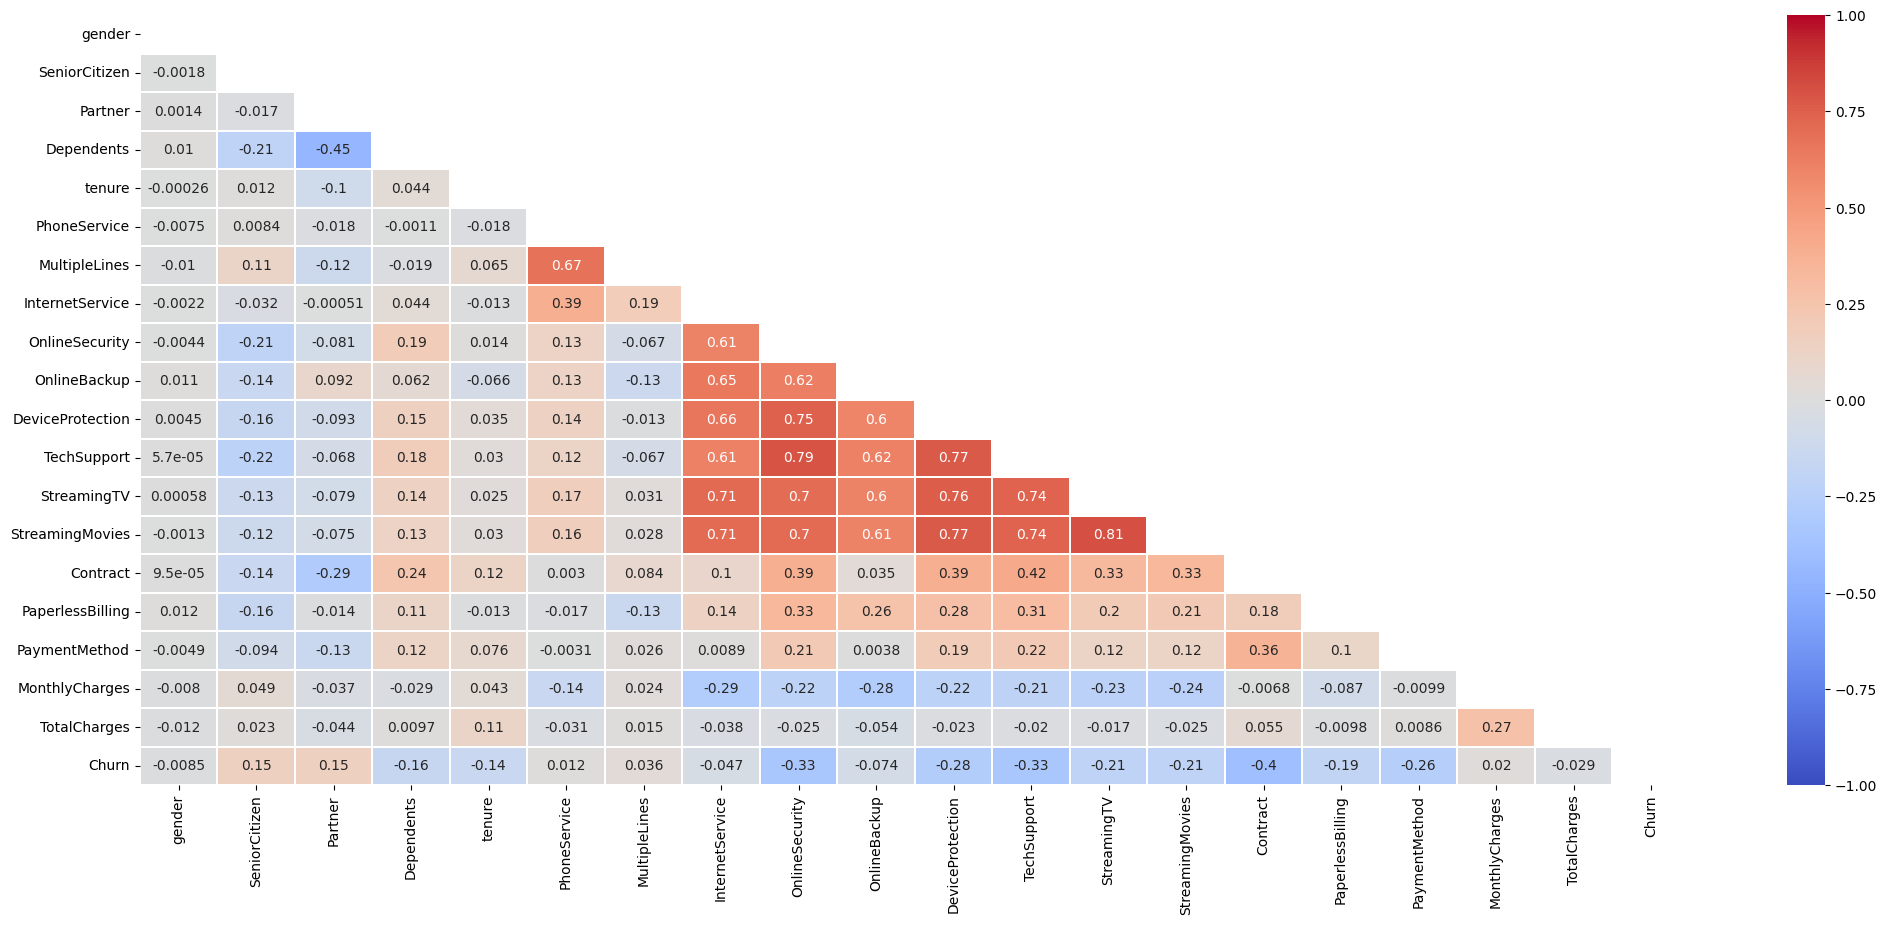

In [61]:
plt.figure(figsize=(25, 10))

corr = df1.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

The distribution of numerical columns.

In [62]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8, 3))
    plt.title(f"Distribution for {feature}")

    sns.histplot(
        frame[feature],
        bins=30,
        kde=True,
        stat="density",
        color=color,
        alpha=0.4
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.show()

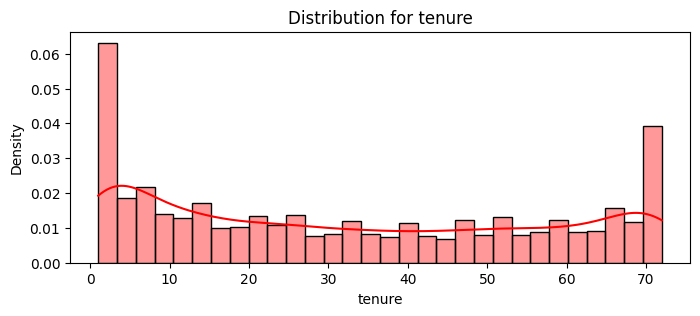

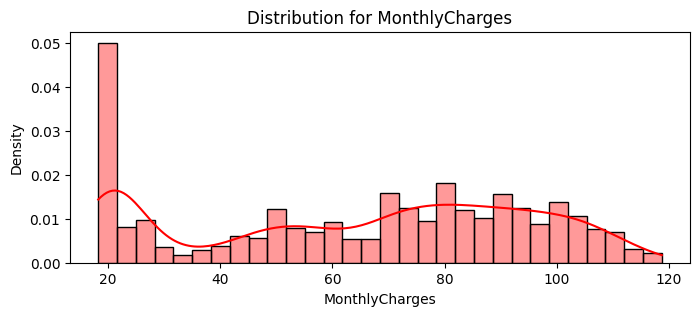

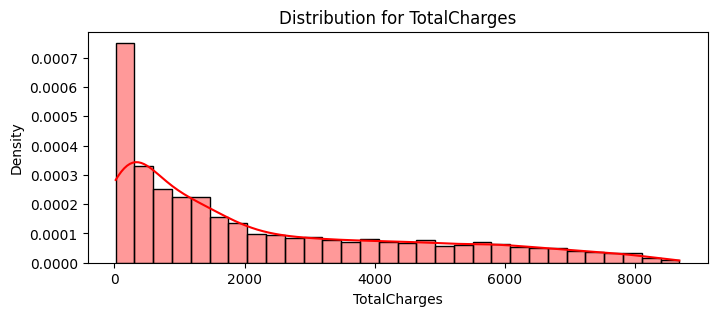

In [63]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

## Data Preprocessing

One more sanity check.


We can make a guess: is TotalCharges == tenure * MonthlyCharges?

In [64]:
df1["Diff"] = df1["TotalCharges"] - df1["tenure"] * df1["MonthlyCharges"]
print(sum(df1["Diff"]== 0))
print(df1["Diff"].describe())

614
count    7032.000000
mean        0.153193
std        67.255326
min      -370.850000
25%       -28.650000
50%         0.000000
75%        28.700000
max       373.250000
Name: Diff, dtype: float64


This analysis shows that TotalCharges is approximately equal to the product of tenure and MonthlyCharges, so MonthlyCharges and TotalCharges can not be seen as independent variables.

In [65]:
df1.drop(columns=["Diff"], inplace=True)

In [66]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.histplot(
    frame[feature],
    bins=30,
    kde=True,
    kde_kws={"bw_adjust": 1.2},
    stat="density",
    alpha=0.4,
    color=color
)

### Train/Test Split

In [75]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Scaling

In [68]:
# data split for logistic regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_lr = ["tenure", "MonthlyCharges"]
cat_lr = [col for col in X_train_raw.columns if col not in num_lr + ["TotalCharges"]]

preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_lr),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_lr)
    ]
)

In [69]:
# data split for tree model
from sklearn.preprocessing import OrdinalEncoder
num_tree = ["tenure", "MonthlyCharges", "TotalCharges"]

cat_tree = [
    col for col in X_train_raw.columns
    if col not in num_tree
]

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_tree),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_tree)
    ]
)

# Modeling

## Model1: Logistic Regression(Baseline)

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_baseline = Pipeline(
    steps=[
        ("preprocess", preprocess_lr),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

## Model2: Logistic Regression + SMOTE

Since `Churn` column is highly imbalanced, try SMOTE.

In [71]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

lr_smote = ImbPipeline(
    steps=[
        ("preprocess", preprocess_lr),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight=None
        ))
    ]
)

## Model3: Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(
    steps=[
        ("preprocess", preprocess_tree),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

## Model4: Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocess_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [74]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocess", preprocess_tree),
        ("model", XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

In [76]:
models = {
    "LR Baseline": lr_baseline,
    "LR + SMOTE": lr_smote,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Evaluation

In [77]:
from sklearn.metrics import roc_auc_score, classification_report

for name, model in models.items():
    model.fit(X_train_raw, y_train)
    y_prob = model.predict_proba(X_test_raw)[:, 1]
    y_pred = model.predict(X_test_raw)

    print(f"\n{name}")
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))


LR Baseline
ROC-AUC: 0.8330248846876602
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


LR + SMOTE
ROC-AUC: 0.8316659850598693
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.75      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407


Decision Tree
ROC-AUC: 0.8132613073390933
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.49      0.76      0.60       374

    accuracy                           0.73      1407
   m

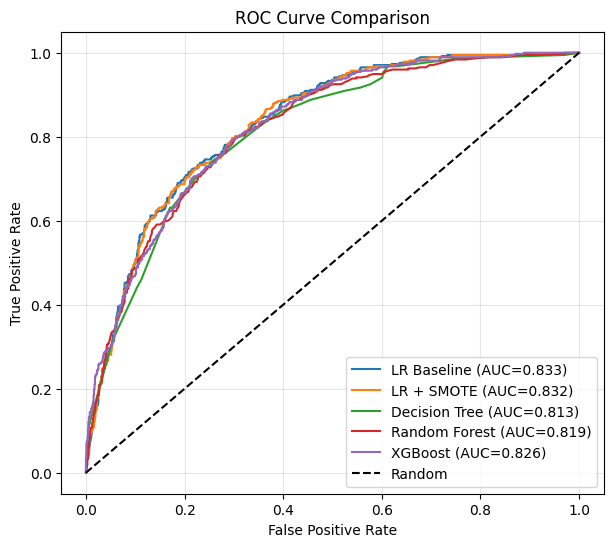

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_raw)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


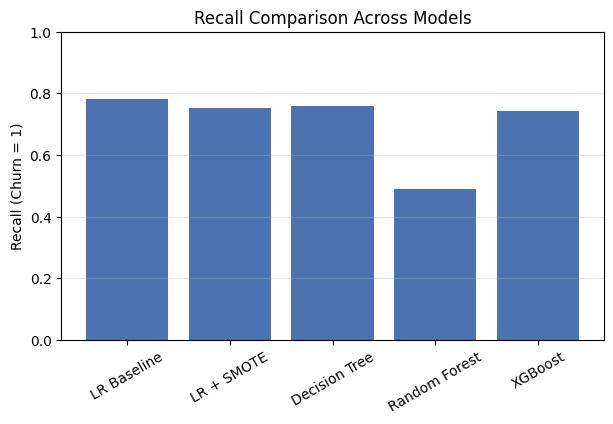

In [80]:
from sklearn.metrics import recall_score

recall_results = []

for name, model in models.items():
    y_pred = model.predict(X_test_raw)
    recall = recall_score(y_test, y_pred, pos_label=1)
    recall_results.append({"Model": name, "Recall (Churn)": recall})

recall_df = pd.DataFrame(recall_results)

plt.figure(figsize=(7, 4))
plt.bar(recall_df["Model"], recall_df["Recall (Churn)"], color="#4C72B0")
plt.ylabel("Recall (Churn = 1)")
plt.title("Recall Comparison Across Models")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()


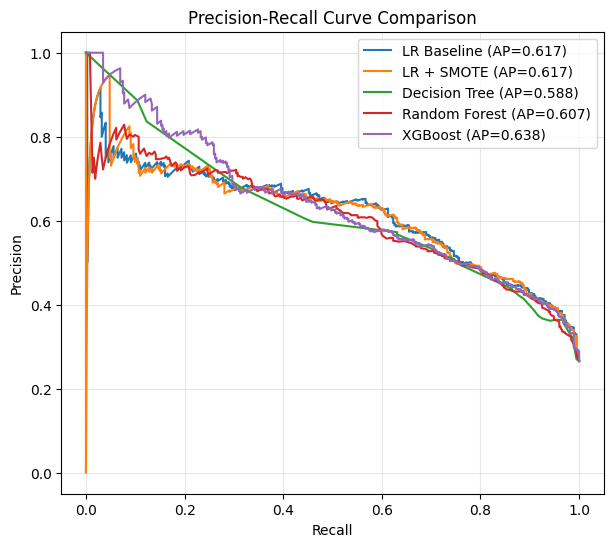

In [81]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_raw)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


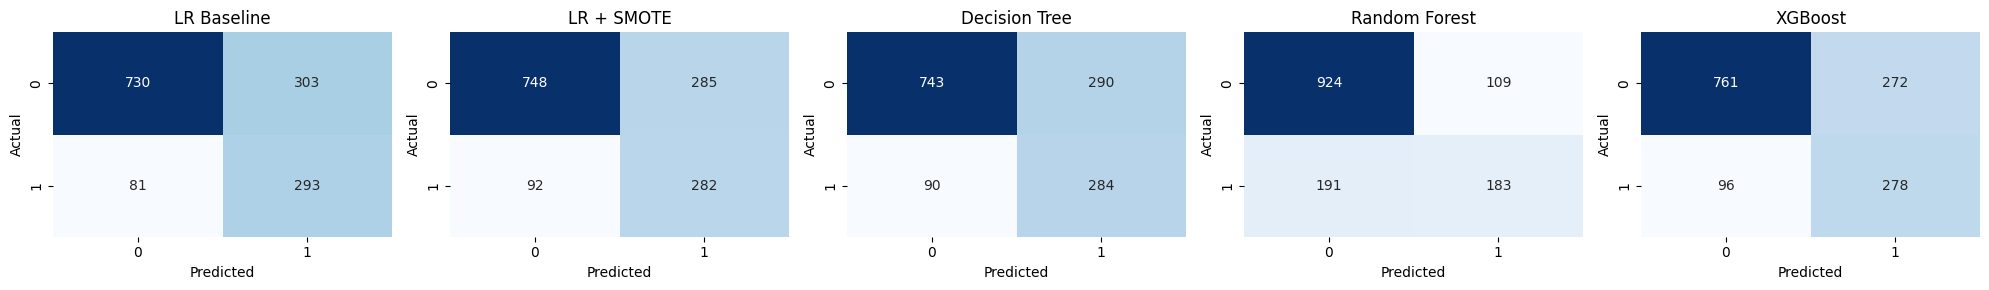

In [83]:
from sklearn.metrics import confusion_matrix

n_models = len(models)
plt.figure(figsize=(4 * n_models, 3))

for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test_raw)
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, n_models, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

summary = []

for name, model in models.items():
    y_pred = model.predict(X_test_raw)
    y_prob = model.predict_proba(X_test_raw)[:, 1]

    summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Churn)": precision_score(y_test, y_pred),
        "Recall (Churn)": recall_score(y_test, y_pred),
        "F1 (Churn)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

summary_df = pd.DataFrame(summary).set_index("Model")
summary_df


,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Model,,,,,
LR Baseline,0.727079,0.491611,0.783422,0.604124,0.833025
LR + SMOTE,0.732054,0.497354,0.754011,0.599362,0.831666
Decision Tree,0.729922,0.494774,0.759358,0.599156,0.813261
Random Forest,0.786780,0.626712,0.489305,0.549550,0.819357
XGBoost,0.738451,0.505455,0.743316,0.601732,0.825534


## Model Evaluation Summary

Given our business objective of cost-effectively identifying and retaining churning customers, **Logistic Regression (Baseline)** emerges as the optimal model. It achieves the highest recall for churn prediction (78%), successfully identifying 293 out of 374 at-risk customers while only missing 81 - the lowest false negative rate among all models. Although this comes with 303 false positives (customers incorrectly predicted to churn), the cost of contacting non-churning customers is typically much lower than losing actual churners. The model also has the highest ROC-AUC (0.833) and offers significant practical advantages: it's interpretable, computationally efficient, and easy to deploy and maintain in production.

In contrast, Random Forest - despite having higher overall accuracy (79%) - performs poorly for our specific use case with only 49% recall, meaning it misses 191 churning customers (51% of all churners). This makes it unsuitable for a retention-focused strategy where the primary goal is to maximize churn detection. The SMOTE version and tree-based models (Decision Tree, XGBoost) show similar recall patterns to the baseline LR but don't provide meaningful improvements to justify their added complexity.

**Recommendation**: Deploy the Logistic Regression Baseline model for production, as it best aligns with our business objective of maximizing churn detection while maintaining simplicity and interpretability.

# Business Insight

The comparison between actual and predicted churn on the test set shows that the logistic regression model prioritizes identifying potential churners, successfully capturing the majority of customers who eventually churn. While this approach introduces a higher number of false positives, it aligns well with churn prevention strategies where the cost of proactive outreach is significantly lower than the cost of losing a customer.

The scatter plot further reveals a clear churn risk pattern: customers with shorter tenure and higher monthly charges are far more likely to be predicted as churn. This suggests that early-stage customers experiencing higher pricing pressure represent the most vulnerable segment. From a business perspective, targeted retention actions—such as onboarding incentives, contract discounts, or early support interventions—should focus on these high-risk customers to maximize retention effectiveness.


In [86]:
best_model = lr_baseline

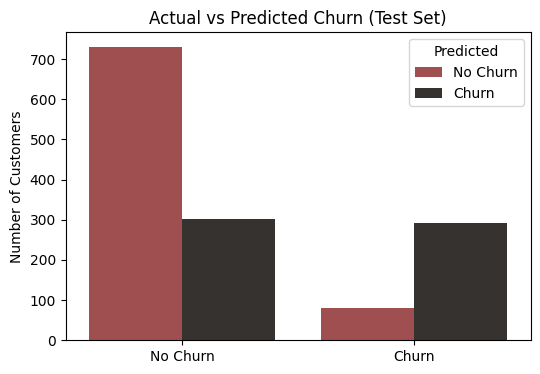

In [90]:
y_test_pred = best_model.predict(X_test_raw)

compare_df = pd.DataFrame({
    "Actual": y_test.map({0: "No Churn", 1: "Churn"}),
    "Predicted": pd.Series(y_test_pred, index=y_test.index).map({0: "No Churn", 1: "Churn"})
})

count_df = (
    compare_df
    .value_counts()
    .reset_index(name="Count")
)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=count_df,
    x="Actual",
    y="Count",
    hue="Predicted",
    palette=["#AC4242", "#37322F"]
)

plt.title("Actual vs Predicted Churn (Test Set)")
plt.ylabel("Number of Customers")
plt.xlabel("")
plt.legend(title="Predicted")
plt.show()


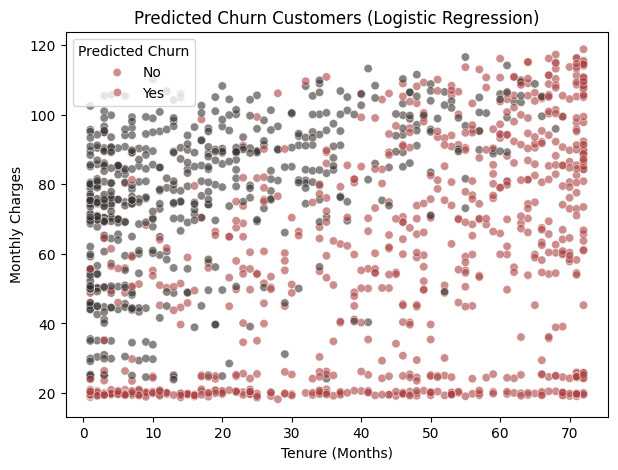

In [91]:
viz_df = X_test_raw.copy()
viz_df["PredictedChurn"] = y_test_pred

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=viz_df,
    x="tenure",
    y="MonthlyCharges",
    hue="PredictedChurn",
    palette={0: "#AC4242", 1: "#37322F"},
    alpha=0.6
)

plt.title("Predicted Churn Customers (Logistic Regression)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.legend(title="Predicted Churn", labels=["No", "Yes"])
plt.show()


In [99]:
# dashboard prepare

# dashboard1
churn_profile_table = df.copy()

churn_profile_table["ChurnLabel"] = churn_profile_table["Churn"].map({
    "No": "No Churn",
    "Yes": "Churn"
})

churn_profile_table.to_csv(
    "tableau_churn_profile.csv",
    index=False
)


In [100]:
# dashboard2
best_model = lr_baseline

y_test_pred = best_model.predict(X_test_raw)
y_test_prob = best_model.predict_proba(X_test_raw)[:, 1]

predicted_churn_table = X_test_raw.copy()

predicted_churn_table["ActualChurn"] = y_test.map({
    0: "No Churn",
    1: "Churn"
})

predicted_churn_table["PredictedChurn"] = pd.Series(
    y_test_pred, index=y_test.index
).map({
    0: "No Churn",
    1: "Churn"
})

predicted_churn_table["ChurnProbability"] = y_test_prob

predicted_churn_table["RiskLevel"] = pd.cut(
    predicted_churn_table["ChurnProbability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)
predicted_churn_table.to_csv(
    "tableau_predicted_churn.csv",
    index=False
)